# Week 4 Task 4 — Monitoring and Drift Detection

This notebook compares the training data with recent customer feature data to check for possible data drift. The goal is to monitor whether the model is receiving data that is different from the data used during training.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from pathlib import Path

In [3]:
reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

In [4]:
DB_NAME = "intern_db"
DB_USER = "postgres"
DB_PASSWORD = "Abdulla11-11"
DB_HOST = "localhost"
DB_PORT = "5432"


def get_connection():
    return psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )

In [5]:
recent_query = """
    SELECT
        c.customer_id,

        COUNT(o.order_id) AS num__total_orders,

        COALESCE(SUM(t.amount), 0) AS num__total_spent,

        COALESCE(AVG(t.amount), 0) AS num__average_order_amount,

        COUNT(
            CASE
                WHEN t.payment_status = 'paid' THEN 1
            END
        ) AS num__successful_payments,

        CASE WHEN c.city = 'Abu Dhabi' THEN 1 ELSE 0 END AS "cat__city_Abu Dhabi",
        CASE WHEN c.city = 'Ajman' THEN 1 ELSE 0 END AS "cat__city_Ajman",
        CASE WHEN c.city = 'Dubai' THEN 1 ELSE 0 END AS "cat__city_Dubai",
        CASE WHEN c.city = 'Sharjah' THEN 1 ELSE 0 END AS "cat__city_Sharjah"

    FROM customers c

    LEFT JOIN orders o
        ON c.customer_id = o.customer_id

    LEFT JOIN transactions t
        ON o.order_id = t.order_id

    GROUP BY c.customer_id, c.city

    ORDER BY c.customer_id;
"""

conn = get_connection()
recent_df = pd.read_sql(recent_query, conn)
conn.close()

recent_df.head()

C:\Users\homam\AppData\Local\Temp\ipykernel_6016\4271367502.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  recent_df = pd.read_sql(recent_query, conn)


,customer_id,num__total_orders,num__total_spent,num__average_order_amount,num__successful_payments,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,1,0,0.00,0.000,0,1,0,0,0
1,2,2,5316.66,2658.330,0,0,1,0,0
2,3,2,5668.17,2834.085,1,1,0,0,0
3,4,0,0.00,0.000,0,0,0,0,1
4,5,0,0.00,0.000,0,0,0,1,0


In [6]:
training_df = pd.read_csv("../data/processed/features.csv")

training_df.head()

,num__total_orders,num__total_spent,num__average_order_amount,num__successful_payments,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah,will_reorder
0,-1.360828,-1.217951,-1.534777,-0.928142,1.0,0.0,0.0,0.0,0.0
1,0.000000,-0.356606,-0.296974,-0.928142,0.0,1.0,0.0,0.0,1.0
2,0.000000,-0.299658,-0.215137,0.457144,1.0,0.0,0.0,0.0,1.0
3,-1.360828,-1.217951,-1.534777,-0.928142,0.0,0.0,0.0,1.0,0.0
4,-1.360828,-1.217951,-1.534777,-0.928142,0.0,0.0,1.0,0.0,0.0


In [7]:
print("Training columns:")
print(training_df.columns.tolist())

print("\nRecent columns:")
print(recent_df.columns.tolist())

Training columns:
['num__total_orders', 'num__total_spent', 'num__average_order_amount', 'num__successful_payments', 'cat__city_Abu Dhabi', 'cat__city_Ajman', 'cat__city_Dubai', 'cat__city_Sharjah', 'will_reorder']

Recent columns:
['customer_id', 'num__total_orders', 'num__total_spent', 'num__average_order_amount', 'num__successful_payments', 'cat__city_Abu Dhabi', 'cat__city_Ajman', 'cat__city_Dubai', 'cat__city_Sharjah']


In [8]:
feature_columns = [
    "num__total_orders",
    "num__total_spent",
    "num__average_order_amount",
    "num__successful_payments",
    "cat__city_Abu Dhabi",
    "cat__city_Ajman",
    "cat__city_Dubai",
    "cat__city_Sharjah"
]

training_features = training_df[feature_columns]
recent_features = recent_df[feature_columns]

print("Training features shape:", training_features.shape)
print("Recent features shape:", recent_features.shape)

Training features shape: (100, 8)
Recent features shape: (100, 8)


In [9]:
training_stats = training_features.describe().T
recent_stats = recent_features.describe().T

comparison_df = pd.DataFrame({
    "training_mean": training_stats["mean"],
    "recent_mean": recent_stats["mean"],
    "mean_difference": recent_stats["mean"] - training_stats["mean"],
    "training_std": training_stats["std"],
    "recent_std": recent_stats["std"],
    "std_difference": recent_stats["std"] - training_stats["std"]
})

comparison_df

,training_mean,recent_mean,mean_difference,training_std,recent_std,std_difference
num__total_orders,0.000000e+00,2.000000,2.000000,1.005038,1.477098,0.472060
num__total_spent,-8.326673e-18,7517.812500,7517.812500,1.005038,6203.603614,6202.598576
num__average_order_amount,-2.220446e-17,3296.116666,3296.116666,1.005038,2158.438976,2157.433938
num__successful_payments,2.220446e-18,0.670000,0.670000,1.005038,0.725509,-0.279529
cat__city_Abu Dhabi,3.100000e-01,0.310000,0.000000,0.464823,0.464823,0.000000
cat__city_Ajman,2.700000e-01,0.270000,0.000000,0.446196,0.446196,0.000000
cat__city_Dubai,2.600000e-01,0.260000,0.000000,0.440844,0.440844,0.000000
cat__city_Sharjah,1.600000e-01,0.160000,0.000000,0.368453,0.368453,0.000000


In [10]:
comparison_df["possible_drift"] = comparison_df["mean_difference"].abs() > 1

comparison_df

,training_mean,recent_mean,mean_difference,training_std,recent_std,std_difference,possible_drift
num__total_orders,0.000000e+00,2.000000,2.000000,1.005038,1.477098,0.472060,True
num__total_spent,-8.326673e-18,7517.812500,7517.812500,1.005038,6203.603614,6202.598576,True
num__average_order_amount,-2.220446e-17,3296.116666,3296.116666,1.005038,2158.438976,2157.433938,True
num__successful_payments,2.220446e-18,0.670000,0.670000,1.005038,0.725509,-0.279529,False
cat__city_Abu Dhabi,3.100000e-01,0.310000,0.000000,0.464823,0.464823,0.000000,False
cat__city_Ajman,2.700000e-01,0.270000,0.000000,0.446196,0.446196,0.000000,False
cat__city_Dubai,2.600000e-01,0.260000,0.000000,0.440844,0.440844,0.000000,False
cat__city_Sharjah,1.600000e-01,0.160000,0.000000,0.368453,0.368453,0.000000,False


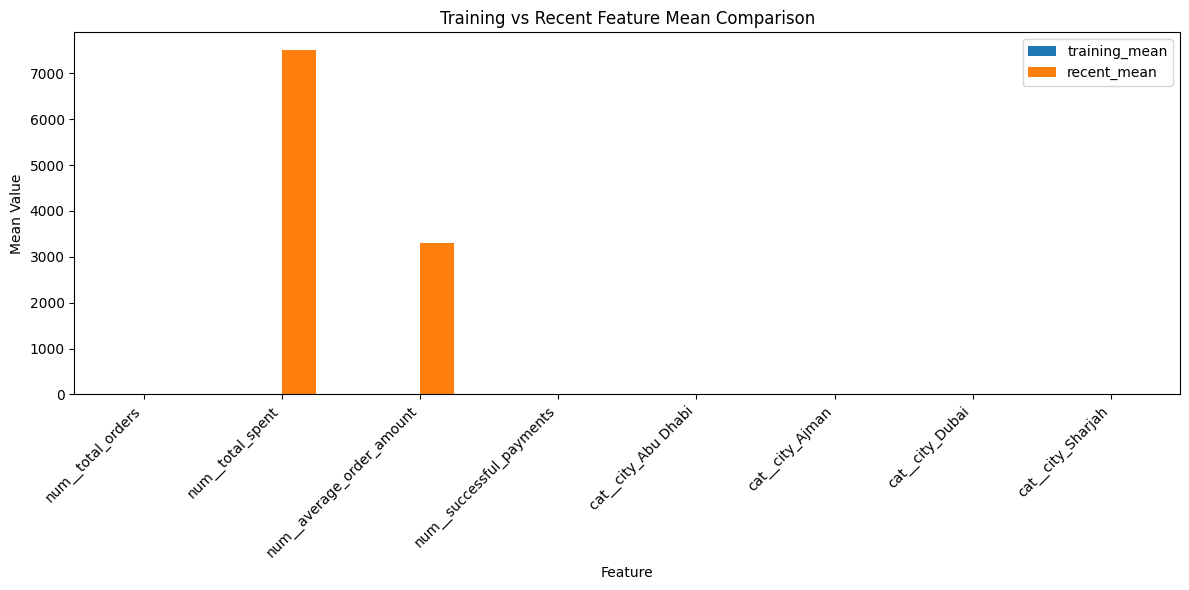

In [11]:
mean_comparison = comparison_df[["training_mean", "recent_mean"]]

mean_comparison.plot(kind="bar", figsize=(12, 6))

plt.title("Training vs Recent Feature Mean Comparison")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(reports_dir / "drift_mean_comparison.png")
plt.show()

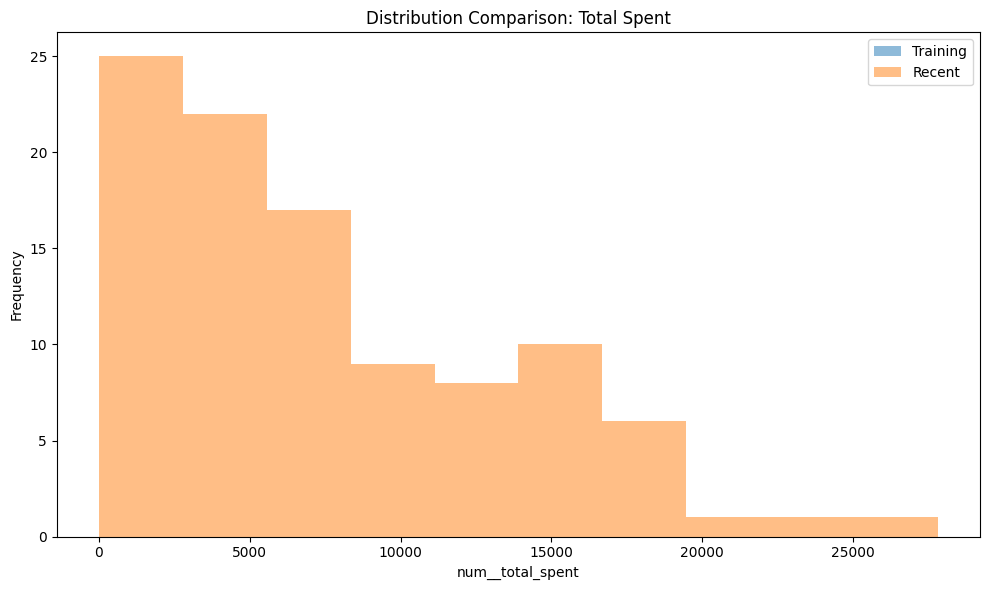

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(training_features["num__total_spent"], alpha=0.5, label="Training")
plt.hist(recent_features["num__total_spent"], alpha=0.5, label="Recent")

plt.title("Distribution Comparison: Total Spent")
plt.xlabel("num__total_spent")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.savefig(reports_dir / "drift_total_spent_histogram.png")
plt.show()

In [13]:
comparison_df.to_csv(reports_dir / "drift_comparison_metrics.csv")

print("Drift comparison metrics saved successfully.")

Drift comparison metrics saved successfully.
